Co musimy zrobić?

Wybrać dwa dowolne miasta (ale różne od Berlina miasta) w których przeanalizujemy rynek mieszkań dostępnych na AirBnB pod kątem tego jakie cechy tych mieszkań (np liczba pokoi, liczba łazienek, powierzchnia itp) ma największy wpływ na cenę w tym mieście - interesuje nas znalezienie miast w których najłatwiej będzie podnieść cenę wynajmu.

Źródło danych: insideairbnb.com/get-the-data.html

Cel: Na podstawie przeprowadzonych analiz, zidentyfikuj miasta, które mają największy potencjał na wzrost cen wynajmu.Wskaż miasta, które mogą przynieść najlepsze zwroty z inwestycji dla stowarzyszenia Mieszkalnik.

Jak to zrobić? Zastosuj techniki uczenia maszynowego, aby zidentyfikować wzorce i zależności w danych. Celem jest stworzenie modelu, który pomoże przewidzieć ceny wynajmu na podstawie różnych czynników.
Możesz użyć algorytmów takich jak regresja liniowa(p-value, R2, AIC), LASSO, eXtreme Gradient Boosting.

Jako zadanie do dla programisty wskazane są algorytmy:
- linear regression model
- LASSO
- Run XGBoost + XAI(Explainable Artificial Intelligence)



Przygotowanie raportu(prezka):
Sporządź raport, który przedstawia wyniki twoich analiz. Raport powinien być zrozumiały dla zarządu stowarzyszenia Mieszkalnik i zawierać jasne rekomendacje dotyczące miast, w których warto rozpocząć inwestycje.
Raport powinien również zawierać przewidywania dotyczące wyników wynajmu dla wybranych miast na podstawie opracowanego modelu.

Kroki do wykonania:
1. Pobierz dane z insideairbnb.com.
2. Przeanalizuj dane przy użyciu technik uczenia maszynowego.
3. Zidentyfikuj kluczowe czynniki wpływające na ceny wynajmu.
4. Opracuj model przewidujący ceny wynajmu.
5. Sporządź raport(prezentacja) z rekomendacjami dla stowarzyszenia Mieszkalnik.

Wybieramy:
Bergamo i Antwerpia

Populacja Bergamo:
Populacja Antwerpii:

Dlaczego te miasta?
Ponieważ szukamy dwóch podobnej wielkości miast z innych państw europejskich, ale też nie stolic żeby nie mieć bardzo dużego data setu, co mogło by(potencjalnie) spowodować problemy natury obliczeniowej.

(przepisane z prezki)Run linear regression model
• Run LASSO
• Run XGBoost + XAI


In [ ]:
import pandas as pd
data = pd.read_csv('/content/drive/MyDrive/3 projekt - AirBnB/listings - Bergamo.csv')
pd.set_option('display.max_columns', None)
data.head(10)

# co do odrzucenia: id, listing_url, scrape_id, last_scraped

# co chcemy:name(z tego będzie trzeba wyciągnąć info takie jak opinie, liczba pokoi itp), description (do sprawdzenia ile mamy zapisów)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,53527563,https://www.airbnb.com/rooms/53527563,20231229163156,2023-12-29,city scrape,Rental unit in Dossena · ★4.43 · 1 bedroom · 2...,NaN,NaN,https://a0.muscache.com/pictures/prohost-api/H...,21763382,https://www.airbnb.com/users/show/21763382,Compagnie Immobiliari Associate,2014-09-25,"Bergamo, Italy",Lasciati incantare dallo splendido mare delle ...,a few days or more,46%,96%,f,https://a0.muscache.com/im/pictures/user/984cf...,https://a0.muscache.com/im/pictures/user/984cf...,Zona 7,88,210,"['email', 'phone']",t,t,NaN,Dossena,NaN,45.879800,9.697220,Entire rental unit,Entire home/apt,4,NaN,1 bath,NaN,2.0,[],$142.00,1,1125,2,2,29,1125,2.0,1120.0,NaN,t,1,1,1,1,2023-12-29,7,1,0,2021-12-08,2023-08-20,4.43,4.71,4.86,5.00,4.57,4.86,4.57,NaN,t,15,15,0,0,0.28
1,583843076540750428,https://www.airbnb.com/rooms/583843076540750428,20231229163156,2023-12-29,city scrape,Rental unit in Plassi · ★4.85 · 1 bedroom · 2 ...,NaN,NaN,https://a0.muscache.com/pictures/prohost-api/H...,392969278,https://www.airbnb.com/users/show/392969278,Marina,2021-03-17,"Passirano, Italy",Sono una dei soci di ToBe e da oltre 20 anni c...,within a day,70%,100%,f,https://a0.muscache.com/im/pictures/user/658cf...,https://a0.muscache.com/im/pictures/user/658cf...,NaN,30,35,"['email', 'phone', 'work_email']",t,t,NaN,Parzanica,NaN,45.736980,10.039873,Entire rental unit,Entire home/apt,4,NaN,1 bath,NaN,2.0,[],$176.00,1,1125,3,3,1125,1125,3.0,1125.0,NaN,t,7,7,7,7,2023-12-29,13,4,0,2022-04-16,2023-09-12,4.85,4.69,4.85,4.77,4.69,4.85,4.62,NaN,t,13,13,0,0,0.63
2,902842874652788522,https://www.airbnb.com/rooms/902842874652788522,20231229163156,2023-12-29,city scrape,Rental unit in Ranzanico · ★4.83 · 1 bedroom ·...,NaN,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,517350267,https://www.airbnb.com/users/show/517350267,Matteo,2023-05-30,NaN,NaN,NaN,NaN,100%,f,https://a0.muscache.com/im/pictures/user/User-...,https://a0.muscache.com/im/pictures/user/User-...,NaN,1,1,"['email', 'phone']",t,t,NaN,Ranzanico,NaN,45.789980,9.950410,Entire rental unit,Entire home/apt,4,NaN,1 bath,NaN,1.0,[],$160.00,2,29,2,2,1125,1125,2.0,1125.0,NaN,t,29,59,89,347,2023-12-29,6,6,0,2023-07-23,2023-09-24,4.83,5.00,5.00,5.00,5.00,5.00,4.83,NaN,f,1,1,0,0,1.13
3,53570244,https://www.airbnb.com/rooms/53570244,20231229163156,2023-12-30,city scrape,Vacation home in Bergamo · ★4.93 · 2 bedrooms ...,NaN,"L’ appartamento, silenzioso e luminoso si trov...",https://a0.muscache.com/pictures/miso/Hosting-...,2831947,https://www.airbnb.com/users/show/2831947,Marzio,2012-07-04,NaN,I was born and live in Bergamo. Married with 2...,within an hour,100%,100%,t,https://a0.muscache.com/im/users/2831947/profi...,ht

In [ ]:
# Zakładam że jeżeli jakaś kolumna zawiera mniej niż 2500 zapisów (około 80% danych to nie jest ona czymś nadającym się do analizy i odrzucam ją na starcie)
min_non_null_count = 2500
data = data.dropna(axis=1, thresh=min_non_null_count)

# Wyświetlenie informacji o danych po usunięciu kolumn
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3048 entries, 0 to 3047
Data columns (total 64 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            3048 non-null   int64  
 1   listing_url                                   3048 non-null   object 
 2   scrape_id                                     3048 non-null   int64  
 3   last_scraped                                  3048 non-null   object 
 4   source                                        3048 non-null   object 
 5   name                                          3048 non-null   object 
 6   picture_url                                   3048 non-null   object 
 7   host_id                                       3048 non-null   int64  
 8   host_url                                      3048 non-null   object 
 9   host_name                                     3048 non-null   o

In [ ]:
#teraz patrzę (optycznie) jak wyglądają moje dane i wybieram kolumny których będę używał do dalszej analizy
pd.set_option('display.max_columns', None)
data.head(5)

,id,listing_url,scrape_id,last_scraped,source,name,picture_url,host_id,host_url,host_name,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms_text,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,53527563,https://www.airbnb.com/rooms/53527563,20231229163156,2023-12-29,city scrape,Rental unit in Dossena · ★4.43 · 1 bedroom · 2...,https://a0.muscache.com/pictures/prohost-api/H...,21763382,https://www.airbnb.com/users/show/21763382,Compagnie Immobiliari Associate,2014-09-25,a few days or more,46%,96%,f,https://a0.muscache.com/im/pictures/user/984cf...,https://a0.muscache.com/im/pictures/user/984cf...,88,210,"['email', 'phone']",t,t,Dossena,45.879800,9.697220,Entire rental unit,Entire home/apt,4,1 bath,2.0,[],$142.00,1,1125,2,2,29,1125,2.0,1120.0,t,1,1,1,1,2023-12-29,7,1,0,2021-12-08,2023-08-20,4.43,4.71,4.86,5.00,4.57,4.86,4.57,t,15,15,0,0,0.28
1,583843076540750428,https://www.airbnb.com/rooms/583843076540750428,20231229163156,2023-12-29,city scrape,Rental unit in Plassi · ★4.85 · 1 bedroom · 2 ...,https://a0.muscache.com/pictures/prohost-api/H...,392969278,https://www.airbnb.com/users/show/392969278,Marina,2021-03-17,within a day,70%,100%,f,https://a0.muscache.com/im/pictures/user/658cf...,https://a0.muscache.com/im/pictures/user/658cf...,30,35,"['email', 'phone', 'work_email']",t,t,Parzanica,45.736980,10.039873,Entire rental unit,Entire home/apt,4,1 bath,2.0,[],$176.00,1,1125,3,3,1125,1125,3.0,1125.0,t,7,7,7,7,2023-12-29,13,4,0,2022-04-16,2023-09-12,4.85,4.69,4.85,4.77,4.69,4.85,4.62,t,13,13,0,0,0.63
2,902842874652788522,https://www.airbnb.com/rooms/902842874652788522,20231229163156,2023-12-29,city scrape,Rental unit in Ranzanico · ★4.83 · 1 bedroom ·...,https://a0.muscache.com/pictures/miso/Hosting-...,517350267,https://www.airbnb.com/users/show/517350267,Matteo,2023-05-30,NaN,NaN,100%,f,https://a0.muscache.com/im/pictures/user/User-...,https://a0.muscache.com/im/pictures/user/User-...,1,1,"['email', 'phone']",t,t,Ranzanico,45.789980,9.950410,Entire rental unit,Entire home/apt,4,1 bath,1.0,[],$160.00,2,29,2,2,1125,1125,2.0,1125.0,t,29,59,89,347,2023-12-29,6,6,0,2023-07-23,2023-09-24,4.83,5.00,5.00,5.00,5.00,5.00,4.83,f,1,1,0,0,1.13
3,53570244,https://www.airbnb.com/rooms/53570244,20231229163156,2023-12-30,city scrape,Vacation home in Bergamo · ★4.93 · 2 bedrooms ...,https://a0.muscache.com/pictures/miso/Hosting-...,2831947,https://www.airbnb.com/users/show/2831947,Marzio,2012-07-04,within an hour,100%,100%,t,https://a0.muscache.com/im/users/2831947/profi...,https://a0.muscache.com/im/users/2831947/profi...,10,22,"['email', 'phone']",t,t,Bergamo,45.687990,9.667020,Entire vacation home,Entire home/apt,6,2 baths,5.0,[],$75.00,3,90,3,6,1125,1125,3.2,1125.0,t,15,39,60,300,2023-12-30,71,40,2,2022-03-14,2023-12-16,4.93,4.90,4.82,4.93,4.97,4.76,4.86,t,6,6,0,0,3.24
4,922282138679070466,https://www.airbnb.com/rooms/922282138679070466,20231229163156,2023-12-30,city scrape,Rental unit in Bergamo · ★4.90 · 1 bedroom · 2...,https://a0.muscache.com/pictures/6f618791-cdfd...,112088465,https://ww

In [ ]:
#sprawdzam sobie jak wyglądają moje dane i przechodzę do ich oczyszczenia
# data.info()
#wybieram kolumny do listy z której będę korzystał przy tworzeniu swoich modeli
columns_to_use = [
    'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_listings_count',
    'host_total_listings_count', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates',
    'beds', 'minimum_nights', 'maximum_nights', 'availability_30', 'availability_60', 'availability_90',
    'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d',
    'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin',
    'review_scores_communication', 'review_scores_location', 'review_scores_value', 'reviews_per_month'
]

# Filtrujemy dane, aby zachować tylko wybrane kolumny, które trafiły do listy
# Używając metody dropna usuwam od razu również wiersze które nie mają danych w danych kolumnach
# - dzięki temu unikam kwestii uzupełniania data setu np średnią itp.
filtered_data = data[columns_to_use + ['price']].dropna()

#Patrzę jak wyglądają dane
filtered_data

,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,latitude,longitude,property_type,room_type,accommodates,beds,minimum_nights,maximum_nights,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,price
0,46%,96%,f,88,210,45.879800,9.697220,Entire rental unit,Entire home/apt,4,2.0,1,1125,1,1,1,1,7,1,0,4.43,4.71,4.86,5.00,4.57,4.86,4.57,0.28,$142.00
1,70%,100%,f,30,35,45.736980,10.039873,Entire rental unit,Entire home/apt,4,2.0,1,1125,7,7,7,7,13,4,0,4.85,4.69,4.85,4.77,4.69,4.85,4.62,0.63,$176.00
3,100%,100%,t,10,22,45.687990,9.667020,Entire vacation home,Entire home/apt,6,5.0,3,90,15,39,60,300,71,40,2,4.93,4.90,4.82,4.93,4.97,4.76,4.86,3.24,$75.00
4,100%,86%,f,3,3,45.699067,9.675348,Entire rental unit,Entire home/apt,4,2.0,2,30,13,22,52,327,10,10,1,4.90,5.00,4.90,4.80,5.00,5.00,4.80,2.22,$100.00
5,0%,0%,f,3,3,45.696320,9.839770,Private room in rental unit,Private room,1,1.0,2,29,0,0,0,131,8,0,0,4.88,4.88,4.88,4.88,4.88,4.50,4.88,0.07,$35.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3038,97%,99%,f,5,6,45.692220,9.679700,Entire condo,Entire home/apt,8,2.0,1,365,0,0,0,0,67,31,0,4.71,4.75,4.79,4.85,4.79,4.53,4.65,2.84,$373.00
3041,80%,100%,f,3,3,45.681590,9.673550,Entire rental unit,Entire home/apt,3,2.0,1,1125,19,38,38,65,2,2,0,4.00,3.50,4.00,4.50,4.50,4.00,3.50,0.70,$86.00
3042,100%,100%,f,6,6,45.697006,9.672669,Entire rental unit,Entire home/apt,6,3.0,1,365,26,56,81,356,5,5,0,4.80,5.00,4.80,4.80,4.80,5.00,4.80,0.86,$229.00
3046,80%,5%,f,2,2,45.694550,9.664433,Entire condo,Entire home/apt,8,5.0,2,28,13,40,68,343,1,0,0,5.00,5.00,5.00,5.00,5.00,5.00,5.00,0.06,$231.00


In [ ]:
filtered_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2177 entries, 0 to 3047
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   host_response_rate           2177 non-null   object 
 1   host_acceptance_rate         2177 non-null   object 
 2   host_is_superhost            2177 non-null   object 
 3   host_listings_count          2177 non-null   int64  
 4   host_total_listings_count    2177 non-null   int64  
 5   latitude                     2177 non-null   float64
 6   longitude                    2177 non-null   float64
 7   property_type                2177 non-null   object 
 8   room_type                    2177 non-null   object 
 9   accommodates                 2177 non-null   int64  
 10  beds                         2177 non-null   float64
 11  minimum_nights               2177 non-null   int64  
 12  maximum_nights               2177 non-null   int64  
 13  availability_30        

In [ ]:
pd.set_option('display.max_columns', None)
filtered_data.head(5)

,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,latitude,longitude,property_type,room_type,accommodates,beds,minimum_nights,maximum_nights,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,price
0,46%,96%,f,88,210,45.879800,9.697220,Entire rental unit,Entire home/apt,4,2.0,1,1125,1,1,1,1,7,1,0,4.43,4.71,4.86,5.00,4.57,4.86,4.57,0.28,$142.00
1,70%,100%,f,30,35,45.736980,10.039873,Entire rental unit,Entire home/apt,4,2.0,1,1125,7,7,7,7,13,4,0,4.85,4.69,4.85,4.77,4.69,4.85,4.62,0.63,$176.00
3,100%,100%,t,10,22,45.687990,9.667020,Entire vacation home,Entire home/apt,6,5.0,3,90,15,39,60,300,71,40,2,4.93,4.90,4.82,4.93,4.97,4.76,4.86,3.24,$75.00
4,100%,86%,f,3,3,45.699067,9.675348,Entire rental unit,Entire home/apt,4,2.0,2,30,13,22,52,327,10,10,1,4.90,5.00,4.90,4.80,5.00,5.00,4.80,2.22,$100.00
5,0%,0%,f,3,3,45.696320,9.839770,Private room in rental unit,Private room,1,1.0,2,29,0,0,0,131,8,0,0,4.88,4.88,4.88,4.88,4.88,4.50,4.88,0.07,$35.00


In [ ]:
# zamieniam wartości procentowe na dziesiętne w kolumnach 'host_response_rate' i 'host_acceptance_rate'
filtered_data['host_response_rate'] = filtered_data['host_response_rate'].str.rstrip('%').astype('float') / 100
filtered_data['host_acceptance_rate'] = filtered_data['host_acceptance_rate'].str.rstrip('%').astype('float') / 100
filtered_data.head(5) #sprawdzam czy wszystko wygląda ok

,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,latitude,longitude,property_type,room_type,accommodates,beds,minimum_nights,maximum_nights,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,price
0,0.46,0.96,f,88,210,45.879800,9.697220,Entire rental unit,Entire home/apt,4,2.0,1,1125,1,1,1,1,7,1,0,4.43,4.71,4.86,5.00,4.57,4.86,4.57,0.28,$142.00
1,0.70,1.00,f,30,35,45.736980,10.039873,Entire rental unit,Entire home/apt,4,2.0,1,1125,7,7,7,7,13,4,0,4.85,4.69,4.85,4.77,4.69,4.85,4.62,0.63,$176.00
3,1.00,1.00,t,10,22,45.687990,9.667020,Entire vacation home,Entire home/apt,6,5.0,3,90,15,39,60,300,71,40,2,4.93,4.90,4.82,4.93,4.97,4.76,4.86,3.24,$75.00
4,1.00,0.86,f,3,3,45.699067,9.675348,Entire rental unit,Entire home/apt,4,2.0,2,30,13,22,52,327,10,10,1,4.90,5.00,4.90,4.80,5.00,5.00,4.80,2.22,$100.00
5,0.00,0.00,f,3,3,45.696320,9.839770,Private room in rental unit,Private room,1,1.0,2,29,0,0,0,131,8,0,0,4.88,4.88,4.88,4.88,4.88,4.50,4.88,0.07,$35.00


In [ ]:
filtered_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2177 entries, 0 to 3047
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   host_response_rate           2177 non-null   float64
 1   host_acceptance_rate         2177 non-null   float64
 2   host_is_superhost            2177 non-null   object 
 3   host_listings_count          2177 non-null   int64  
 4   host_total_listings_count    2177 non-null   int64  
 5   latitude                     2177 non-null   float64
 6   longitude                    2177 non-null   float64
 7   property_type                2177 non-null   object 
 8   room_type                    2177 non-null   object 
 9   accommodates                 2177 non-null   int64  
 10  beds                         2177 non-null   float64
 11  minimum_nights               2177 non-null   int64  
 12  maximum_nights               2177 non-null   int64  
 13  availability_30        

In [ ]:
# Przekształcam kolumnę 'host_is_superhost' na wartości numeryczne - używam funkcji map dla ułatniewnia (na ten moment - jeżeli wystarczy czasu użyję OHE)

# print("Unikalne wartości w kolumnie 'host_is_superhost':") #sprawadzam sobie czy cały wiersz zawiera tylko wartości "t" i "f"
# print(filtered_data['host_is_superhost'].unique())
filtered_data['host_is_superhost'] = filtered_data['host_is_superhost'].map({'t': 1, 'f': 0}) # mapuję po wartościach
filtered_data.head(5)

,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,latitude,longitude,property_type,room_type,accommodates,beds,minimum_nights,maximum_nights,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,price
0,0.46,0.96,0,88,210,45.879800,9.697220,Entire rental unit,Entire home/apt,4,2.0,1,1125,1,1,1,1,7,1,0,4.43,4.71,4.86,5.00,4.57,4.86,4.57,0.28,$142.00
1,0.70,1.00,0,30,35,45.736980,10.039873,Entire rental unit,Entire home/apt,4,2.0,1,1125,7,7,7,7,13,4,0,4.85,4.69,4.85,4.77,4.69,4.85,4.62,0.63,$176.00
3,1.00,1.00,1,10,22,45.687990,9.667020,Entire vacation home,Entire home/apt,6,5.0,3,90,15,39,60,300,71,40,2,4.93,4.90,4.82,4.93,4.97,4.76,4.86,3.24,$75.00
4,1.00,0.86,0,3,3,45.699067,9.675348,Entire rental unit,Entire home/apt,4,2.0,2,30,13,22,52,327,10,10,1,4.90,5.00,4.90,4.80,5.00,5.00,4.80,2.22,$100.00
5,0.00,0.00,0,3,3,45.696320,9.839770,Private room in rental unit,Private room,1,1.0,2,29,0,0,0,131,8,0,0,4.88,4.88,4.88,4.88,4.88,4.50,4.88,0.07,$35.00


In [ ]:
print("Unikalne wartości w kolumnie 'property_type':") #sprawadzam jakie są tu unikalne wartości
print(filtered_data['property_type'].unique())

Unikalne wartości w kolumnie 'property_type':
['Entire rental unit' 'Entire vacation home' 'Private room in rental unit'
 'Entire condo' 'Entire serviced apartment' 'Room in bed and breakfast'
 'Room in boutique hotel' 'Entire home' 'Private room in condo'
 'Room in aparthotel' 'Private room in villa'
 'Private room in vacation home' 'Private room in bed and breakfast'
 'Entire loft' 'Tiny home' 'Entire villa' 'Entire cottage'
 'Entire townhouse' 'Private room in home' 'Entire chalet'
 'Entire bed and breakfast' 'Private room in hostel'
 'Private room in serviced apartment' 'Private room in tower' 'Hut'
 'Entire cabin' 'Entire guest suite' 'Shared room in rental unit'
 'Room in hotel' 'Private room in farm stay' 'Private room in guesthouse'
 'Farm stay' 'Barn' 'Tower' 'Entire guesthouse'
 'Room in serviced apartment' 'Private room' 'Private room in loft'
 'Private room in townhouse' 'Tent' 'Castle' 'Shared room in home'
 'Entire in-law']


In [ ]:
# Wg mnie za dużo tych unikatowych wartości - więc dropuję kolumnę
filtered_data = filtered_data.drop(columns=['property_type'])
filtered_data.head(5)

,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,latitude,longitude,room_type,accommodates,beds,minimum_nights,maximum_nights,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,price
0,0.46,0.96,0,88,210,45.879800,9.697220,Entire home/apt,4,2.0,1,1125,1,1,1,1,7,1,0,4.43,4.71,4.86,5.00,4.57,4.86,4.57,0.28,$142.00
1,0.70,1.00,0,30,35,45.736980,10.039873,Entire home/apt,4,2.0,1,1125,7,7,7,7,13,4,0,4.85,4.69,4.85,4.77,4.69,4.85,4.62,0.63,$176.00
3,1.00,1.00,1,10,22,45.687990,9.667020,Entire home/apt,6,5.0,3,90,15,39,60,300,71,40,2,4.93,4.90,4.82,4.93,4.97,4.76,4.86,3.24,$75.00
4,1.00,0.86,0,3,3,45.699067,9.675348,Entire home/apt,4,2.0,2,30,13,22,52,327,10,10,1,4.90,5.00,4.90,4.80,5.00,5.00,4.80,2.22,$100.00
5,0.00,0.00,0,3,3,45.696320,9.839770,Private room,1,1.0,2,29,0,0,0,131,8,0,0,4.88,4.88,4.88,4.88,4.88,4.50,4.88,0.07,$35.00


In [ ]:
print("Unikalne wartości w kolumnie 'room_type':") #analogiczne sprawadzam jakie są tu wartości
print(filtered_data['room_type'].unique())

Unikalne wartości w kolumnie 'room_type':
['Entire home/apt' 'Private room' 'Hotel room' 'Shared room']


In [ ]:
# tu jest ich zdecydowanie mniej unikatowych kombinacji więc mogę tu zrobić OHE
from sklearn.preprocessing import OneHotEncoder
# One-hot encoding dla kolumny room_type przy użyciu OneHotEncoder
encoder = OneHotEncoder(drop='first', sparse=False)
encoded_columns = encoder.fit_transform(filtered_data[['room_type']])

# Tworzymy DataFrame z zakodowanymi kolumnami
encoded_cols_df = pd.DataFrame(encoded_columns, columns=encoder.get_feature_names_out(['room_type']))

# Łączymy zakodowane kolumny z oryginalnym DataFrame
filtered_data = pd.concat([filtered_data, encoded_cols_df], axis=1).drop(columns=['room_type'])
filtered_data.head(5)

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,beds,minimum_nights,maximum_nights,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,price,room_type_Hotel room,room_type_Private room,room_type_Shared room
0,0.46,0.96,0.0,88.0,210.0,45.879800,9.697220,4.0,2.0,1.0,1125.0,1.0,1.0,1.0,1.0,7.0,1.0,0.0,4.43,4.71,4.86,5.00,4.57,4.86,4.57,0.28,$142.00,0.0,0.0,0.0
1,0.70,1.00,0.0,30.0,35.0,45.736980,10.039873,4.0,2.0,1.0,1125.0,7.0,7.0,7.0,7.0,13.0,4.0,0.0,4.85,4.69,4.85,4.77,4.69,4.85,4.62,0.63,$176.00,0.0,0.0,0.0
3,1.00,1.00,1.0,10.0,22.0,45.687990,9.667020,6.0,5.0,3.0,90.0,15.0,39.0,60.0,300.0,71.0,40.0,2.0,4.93,4.90,4.82,4.93,4.97,4.76,4.86,3.24,$75.00,0.0,0.0,0.0
4,1.00,0.86,0.0,3.0,3.0,45.699067,9.675348,4.0,2.0,2.0,30.0,13.0,22.0,52.0,327.0,10.0,10.0,1.0,4.90,5.00,4.90,4.80,5.00,5.00,4.80,2.22,$100.00,0.0,1.0,0.0
5,0.00,0.00,0.0,3.0,3.0,45.696320,9.839770,1.0,1.0,2.0,29.0,0.0,0.0,0.0,131.0,8.0,0.0,0.0,4.88,4.88,4.88,4.88,4.88,4.50,4.88,0.07,$35.00,0.0,0.0,0.0


In [ ]:
# Konwertujemy cenę na wartość numeryczną
filtered_data['price'] = filtered_data['price'].replace('[\$,]', '', regex=True).astype(float)
filtered_data.head(5)

,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,beds,minimum_nights,maximum_nights,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,price,room_type_Hotel room,room_type_Private room,room_type_Shared room
0,0.46,0.96,0.0,88.0,210.0,45.879800,9.697220,4.0,2.0,1.0,1125.0,1.0,1.0,1.0,1.0,7.0,1.0,0.0,4.43,4.71,4.86,5.00,4.57,4.86,4.57,0.28,142.0,0.0,0.0,0.0
1,0.70,1.00,0.0,30.0,35.0,45.736980,10.039873,4.0,2.0,1.0,1125.0,7.0,7.0,7.0,7.0,13.0,4.0,0.0,4.85,4.69,4.85,4.77,4.69,4.85,4.62,0.63,176.0,0.0,0.0,0.0
3,1.00,1.00,1.0,10.0,22.0,45.687990,9.667020,6.0,5.0,3.0,90.0,15.0,39.0,60.0,300.0,71.0,40.0,2.0,4.93,4.90,4.82,4.93,4.97,4.76,4.86,3.24,75.0,0.0,0.0,0.0
4,1.00,0.86,0.0,3.0,3.0,45.699067,9.675348,4.0,2.0,2.0,30.0,13.0,22.0,52.0,327.0,10.0,10.0,1.0,4.90,5.00,4.90,4.80,5.00,5.00,4.80,2.22,100.0,0.0,1.0,0.0
5,0.00,0.00,0.0,3.0,3.0,45.696320,9.839770,1.0,1.0,2.0,29.0,0.0,0.0,0.0,131.0,8.0,0.0,0.0,4.88,4.88,4.88,4.88,4.88,4.50,4.88,0.07,35.0,0.0,0.0,0.0


In [ ]:
filtered_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2760 entries, 0 to 2176
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   host_response_rate           2177 non-null   float64
 1   host_acceptance_rate         2177 non-null   float64
 2   host_is_superhost            2177 non-null   float64
 3   host_listings_count          2177 non-null   float64
 4   host_total_listings_count    2177 non-null   float64
 5   latitude                     2177 non-null   float64
 6   longitude                    2177 non-null   float64
 7   accommodates                 2177 non-null   float64
 8   beds                         2177 non-null   float64
 9   minimum_nights               2177 non-null   float64
 10  maximum_nights               2177 non-null   float64
 11  availability_30              2177 non-null   float64
 12  availability_60              2177 non-null   float64
 13  availability_90        

Minimalna wartość: 18.0
Maksymalna wartość: 8500.0


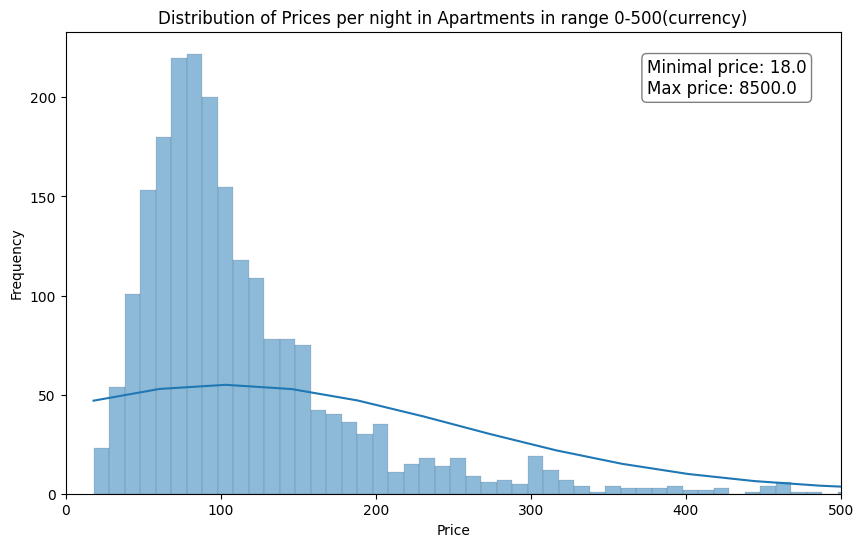

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Wyciągnięcie kolumny 'price'
price_data = filtered_data['price']

# price_data.head(10)

# Wypisanie wartości minimalnej i maksymalnej
min_price = price_data.min()
max_price = price_data.max()
print(f"Minimalna wartość: {min_price}")
print(f"Maksymalna wartość: {max_price}")

# Obliczenie liczby koszyków (bins)
bin_width = 10
num_bins = int((max_price - min_price) / bin_width)

# Wizualizacja rozkładu cen
plt.figure(figsize=(10, 6))
sns.histplot(price_data, kde=True, bins=num_bins)
plt.title('Distribution of Prices per night in Apartments in range 0-500(currency)')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.xlim(0, 500)  # Ustawienie zakresu osi X od 0 do 500

# Dodanie ramki z informacjami o minimalnej i maksymalnej wartości
textstr = f'Minimal price: {min_price}\nMax price: {max_price}'
props = dict(boxstyle='round', facecolor='white', alpha=0.5)
plt.text(0.75, 0.9, textstr, transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='center', bbox=props)

plt.show()

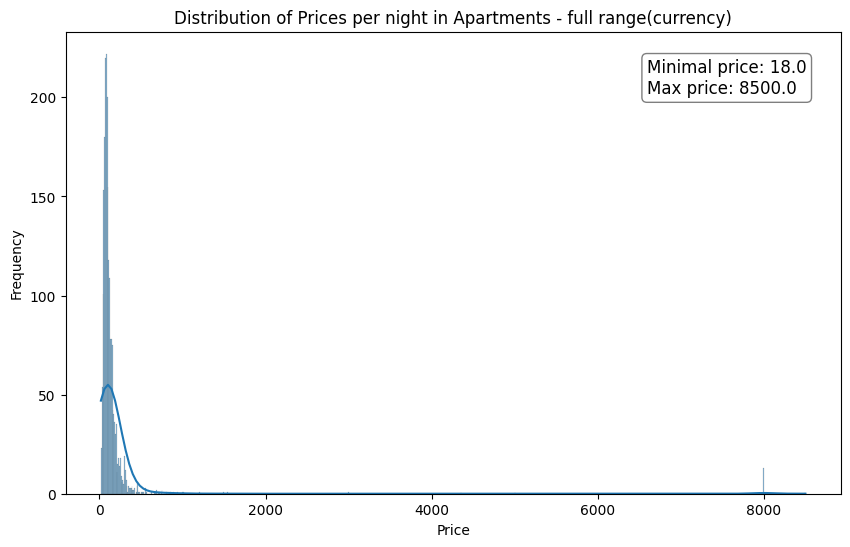

In [ ]:
# Obliczenie liczby koszyków (bins)
bin_width = 10
num_bins = int((max_price - min_price) / bin_width)

# Wizualizacja rozkładu cen
plt.figure(figsize=(10, 6))
sns.histplot(price_data, kde=True, bins=num_bins)
plt.title('Distribution of Prices per night in Apartments - full range(currency)')
plt.xlabel('Price')
plt.ylabel('Frequency')
# plt.xlim(0, 500)  # Ustawienie zakresu osi X od 0 do 500

# Dodanie ramki z informacjami o minimalnej i maksymalnej wartości
textstr = f'Minimal price: {min_price}\nMax price: {max_price}'
props = dict(boxstyle='round', facecolor='white', alpha=0.5)
plt.text(0.75, 0.9, textstr, transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='center', bbox=props)

plt.show()

In [ ]:
import pandas as pd
import folium
from geopy.distance import geodesic

# Usuwanie wierszy z NaN w kolumnach 'latitude' i 'longitude'
filtered_data_map = filtered_data.dropna(subset=['latitude', 'longitude'])

# Współrzędne centrum Bergamo
bergamo_center = (45.6982642, 9.6772698)

# Tworzenie mapy
m = folium.Map(location=bergamo_center, zoom_start=10)

# Dodanie markerów dla apartamentów
for idx, row in filtered_data_map.iterrows():
    folium.CircleMarker(
        location=(row['latitude'], row['longitude']),
        radius=3,  # Wielkość kropki
        color='blue',
        fill=True,
        fill_color='blue'
    ).add_to(m)

# Wyświetlenie mapy
m.save('apartments_map.html')
m


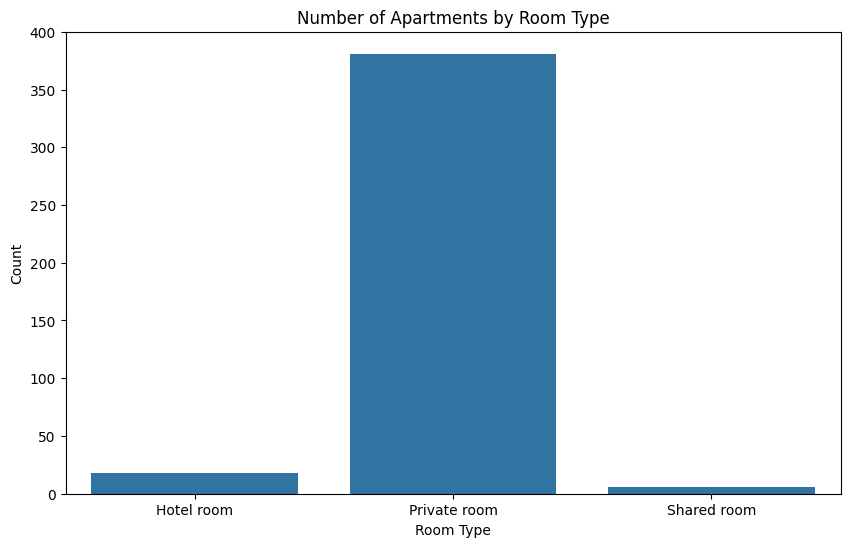

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Zliczanie apartamentów dla każdego typu
room_type_counts = {
    'Hotel room': filtered_data['room_type_Hotel room'].sum(),
    'Private room': filtered_data['room_type_Private room'].sum(),
    'Shared room': filtered_data['room_type_Shared room'].sum()
}

# Tworzenie DataFrame z wynikami zliczania
room_type_df = pd.DataFrame(list(room_type_counts.items()), columns=['Room Type', 'Count'])

# Wizualizacja wyników
plt.figure(figsize=(10, 6))
sns.barplot(x='Room Type', y='Count', data=room_type_df)
plt.title('Number of Apartments by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.show()

In [ ]:
#Zaciekawił mnie fakt, że tylko około 400 apartamentów zostało przypisanych do danej kategorii - więc to sprawdzam
import pandas as pd
# Znalezienie wierszy, w których wszystkie trzy kolumny mają wartość 0
no_room_type_rows = filtered_data[
    (filtered_data['room_type_Hotel room'] == 0) &
    (filtered_data['room_type_Private room'] == 0) &
    (filtered_data['room_type_Shared room'] == 0)
]

# Wyświetlenie wierszy
print("Wiersze, w których wszystkie trzy kolumny mają wartość 0:")
print(no_room_type_rows)

Wiersze, w których wszystkie trzy kolumny mają wartość 0:
      host_response_rate  host_acceptance_rate  host_is_superhost  \
0                   0.46                  0.96                0.0   
1                   0.70                  1.00                0.0   
3                   1.00                  1.00                1.0   
5                   0.00                  0.00                0.0   
6                   1.00                  1.00                1.0   
...                  ...                   ...                ...   
2154                 NaN                   NaN                NaN   
2160                 NaN                   NaN                NaN   
2163                 NaN                   NaN                NaN   
2175                 NaN                   NaN                NaN   
2176                 NaN                   NaN                NaN   

      host_listings_count  host_total_listings_count  latitude  longitude  \
0                    88.0           

In [ ]:
# dzięki powyższej analizie zauwarzyłem że bardzo wiele kolumn
# z tych opisujących rodzaj pokoju ma 0 (czyli brak danych) we wszystkich 3 kolumnach jednocześniem tak więc decyduję o ich usunięciu z dalszej analizy
filtered_data = filtered_data.drop(columns=['room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room'])

In [ ]:
# Sprawdzam jak wyglądają moje dane i czy nadają się już do analizy:
filtered_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2760 entries, 0 to 2176
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   host_response_rate           2177 non-null   float64
 1   host_acceptance_rate         2177 non-null   float64
 2   host_is_superhost            2177 non-null   float64
 3   host_listings_count          2177 non-null   float64
 4   host_total_listings_count    2177 non-null   float64
 5   latitude                     2177 non-null   float64
 6   longitude                    2177 non-null   float64
 7   accommodates                 2177 non-null   float64
 8   beds                         2177 non-null   float64
 9   minimum_nights               2177 non-null   float64
 10  maximum_nights               2177 non-null   float64
 11  availability_30              2177 non-null   float64
 12  availability_60              2177 non-null   float64
 13  availability_90        

In [ ]:
# Dodatkowo sprawdzam czy nie ma braków w danych?
print(filtered_data.isnull().sum()) # - okazuje się że 583 wartości to NaN - trochę nie wiem skąd one się teraz wzięły.. do zbadania

host_response_rate             583
host_acceptance_rate           583
host_is_superhost              583
host_listings_count            583
host_total_listings_count      583
latitude                       583
longitude                      583
accommodates                   583
beds                           583
minimum_nights                 583
maximum_nights                 583
availability_30                583
availability_60                583
availability_90                583
availability_365               583
number_of_reviews              583
number_of_reviews_ltm          583
number_of_reviews_l30d         583
review_scores_rating           583
review_scores_accuracy         583
review_scores_cleanliness      583
review_scores_checkin          583
review_scores_communication    583
review_scores_location         583
review_scores_value            583
reviews_per_month              583
price                          583
dtype: int64


In [ ]:
# Pobranie listy nagłówków kolumn
column_headers = filtered_data.columns.tolist()

column_headers

['host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_listings_count',
 'host_total_listings_count',
 'latitude',
 'longitude',
 'accommodates',
 'beds',
 'minimum_nights',
 'maximum_nights',
 'availability_30',
 'availability_60',
 'availability_90',
 'availability_365',
 'number_of_reviews',
 'number_of_reviews_ltm',
 'number_of_reviews_l30d',
 'review_scores_rating',
 'review_scores_accuracy',
 'review_scores_cleanliness',
 'review_scores_checkin',
 'review_scores_communication',
 'review_scores_location',
 'review_scores_value',
 'reviews_per_month',
 'price']

In [ ]:
from sklearn.preprocessing import StandardScaler

# Lista kolumn do standaryzacji
# columns_to_scale = ['host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_listings_count', 'host_total_listings_count', 'latitude', 'longitude', 'accommodates', 'beds', 'minimum_nights', 'maximum_nights', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'reviews_per_month', 'price', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room']
columns_to_scale = filtered_data.columns.tolist()

# Inicjalizacja standardyzatora
scaler = StandardScaler()

# Standaryzacja danych
filtered_data[columns_to_scale] = scaler.fit_transform(filtered_data[columns_to_scale])

print(filtered_data.head()) #drukujemy żeby sobie zobaczyć jak wyglądają te dane po standaryzacji

   host_response_rate  host_acceptance_rate  host_is_superhost  \
0           -3.317013              0.288734          -0.755452   
1           -1.702825              0.477992          -0.755452   
3            0.314910              0.477992           1.323712   
4            0.314910             -0.184412          -0.755452   
5           -6.410874             -4.253462          -0.755452   

   host_listings_count  host_total_listings_count  latitude  longitude  \
0             1.620838                   2.971122  1.329621  -0.439564   
1             0.419998                   0.338412 -0.087425   1.636571   
3             0.005915                   0.142839 -0.573499  -0.622546   
4            -0.139013                  -0.142998 -0.463590  -0.572084   
5            -0.139013                  -0.142998 -0.490850   0.424147   

   accommodates      beds  minimum_nights  maximum_nights  availability_30  \
0     -0.012838 -0.314343       -0.324377        1.425780        -1.449469   
1 

In [ ]:
filtered_data.head(5) #łatwiej się na to patrzy

,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,beds,minimum_nights,maximum_nights,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,price
0,-3.317013,0.288734,-0.755452,1.620838,2.971122,1.329621,-0.439564,-0.012838,-0.314343,-0.324377,1.425780,-1.449469,-1.672006,-1.814532,-1.800325,-0.427618,-0.587976,-0.451825,-0.860004,-0.192261,0.222122,0.556931,-0.881227,0.405251,-0.225637,-0.613459,-0.055458
1,-1.702825,0.477992,-0.755452,0.419998,0.338412,-0.087425,1.636571,-0.012838,-0.314343,-0.324377,1.425780,-0.886892,-1.397026,-1.629245,-1.751770,-0.354825,-0.451929,-0.451825,0.256459,-0.248236,0.195730,-0.208413,-0.496990,0.373903,-0.105800,-0.438721,-0.003857
3,0.314910,0.477992,1.323712,0.005915,0.142839,-0.573499,-0.622546,0.967787,1.354742,0.190511,-0.769040,-0.136789,0.069534,0.007461,0.619335,0.348840,1.180640,0.944376,0.469119,0.339501,0.116553,0.324000,0.399563,0.091769,0.469418,0.864323,-0.157144
4,0.314910,-0.184412,-0.755452,-0.139013,-0.142998,-0.463590,-0.572084,-0.012838,-0.314343,-0.066933,-0.896276,-0.324315,-0.709576,-0.239589,0.837833,-0.391222,-0.179834,0.246275,0.389371,0.619375,0.327692,-0.108586,0.495622,0.844125,0.325614,0.355087,-0.119201
5,-6.410874,-4.253462,-0.755452,-0.139013,-0.142998,-0.490850,0.424147,-1.483775,-0.870705,-0.066933,-0.898397,-1.543232,-1.717836,-1.845413,-0.748299,-0.415486,-0.633325,-0.451825,0.336206,0.283526,0.274907,0.157621,0.111385,-0.723283,0.517353,-0.718302,-0.217852


In [ ]:
filtered_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2760 entries, 0 to 2176
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   host_response_rate           2177 non-null   float64
 1   host_acceptance_rate         2177 non-null   float64
 2   host_is_superhost            2177 non-null   float64
 3   host_listings_count          2177 non-null   float64
 4   host_total_listings_count    2177 non-null   float64
 5   latitude                     2177 non-null   float64
 6   longitude                    2177 non-null   float64
 7   accommodates                 2177 non-null   float64
 8   beds                         2177 non-null   float64
 9   minimum_nights               2177 non-null   float64
 10  maximum_nights               2177 non-null   float64
 11  availability_30              2177 non-null   float64
 12  availability_60              2177 non-null   float64
 13  availability_90        

In [ ]:
print(filtered_data.isnull().values.any()) # - sprawdzam czy są jakieś null'e (NaN-y) - już do tego doszedłem że jest 583, kilka komórek wyżej

True


In [ ]:
print(filtered_data[filtered_data.isnull().any(axis=1)])

      host_response_rate  host_acceptance_rate  host_is_superhost  \
2                    NaN                   NaN                NaN   
10                   NaN                   NaN                NaN   
18                   NaN                   NaN                NaN   
20                   NaN                   NaN                NaN   
24                   NaN                   NaN                NaN   
...                  ...                   ...                ...   
2160                 NaN                   NaN                NaN   
2163                 NaN                   NaN                NaN   
2167                 NaN                   NaN                NaN   
2175                 NaN                   NaN                NaN   
2176                 NaN                   NaN                NaN   

      host_listings_count  host_total_listings_count  latitude  longitude  \
2                     NaN                        NaN       NaN        NaN   
10               

In [ ]:
# Sprawdzenie liczby wierszy zawierających przynajmniej jedną wartość NaN
num_rows_with_nan = filtered_data.isnull().any(axis=1).sum()
"Liczba wierszy zawierających przynajmniej jedną wartość NaN:", num_rows_with_nan

('Liczba wierszy zawierających przynajmniej jedną wartość NaN:', 583)

In [ ]:
filtered_data = filtered_data.dropna() #usuwam cały wiersz jeżeli zawiera chociaż jeden NaN

In [ ]:
filtered_data # - sprawdzam sobie optycznie jak wyglądają te dane

,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,beds,minimum_nights,maximum_nights,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,price
0,-3.317013,0.288734,-0.755452,1.620838,2.971122,1.329621,-0.439564,-0.012838,-0.314343,-0.324377,1.425780,-1.449469,-1.672006,-1.814532,-1.800325,-0.427618,-0.587976,-0.451825,-0.860004,-0.192261,0.222122,0.556931,-0.881227,0.405251,-0.225637,-0.613459,-0.055458
1,-1.702825,0.477992,-0.755452,0.419998,0.338412,-0.087425,1.636571,-0.012838,-0.314343,-0.324377,1.425780,-0.886892,-1.397026,-1.629245,-1.751770,-0.354825,-0.451929,-0.451825,0.256459,-0.248236,0.195730,-0.208413,-0.496990,0.373903,-0.105800,-0.438721,-0.003857
3,0.314910,0.477992,1.323712,0.005915,0.142839,-0.573499,-0.622546,0.967787,1.354742,0.190511,-0.769040,-0.136789,0.069534,0.007461,0.619335,0.348840,1.180640,0.944376,0.469119,0.339501,0.116553,0.324000,0.399563,0.091769,0.469418,0.864323,-0.157144
4,0.314910,-0.184412,-0.755452,-0.139013,-0.142998,-0.463590,-0.572084,-0.012838,-0.314343,-0.066933,-0.896276,-0.324315,-0.709576,-0.239589,0.837833,-0.391222,-0.179834,0.246275,0.389371,0.619375,0.327692,-0.108586,0.495622,0.844125,0.325614,0.355087,-0.119201
5,-6.410874,-4.253462,-0.755452,-0.139013,-0.142998,-0.490850,0.424147,-1.483775,-0.870705,-0.066933,-0.898397,-1.543232,-1.717836,-1.845413,-0.748299,-0.415486,-0.633325,-0.451825,0.336206,0.283526,0.274907,0.157621,0.111385,-0.723283,0.517353,-0.718302,-0.217852
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3038,0.113137,0.430678,-0.755452,-0.097605,-0.097866,-0.531530,-0.545718,1.948412,-0.314343,-0.324377,-0.185875,-1.543232,-1.717836,-1.845413,-1.808417,0.300311,0.772497,-0.451825,-0.115695,-0.080311,0.037376,0.057793,-0.176792,-0.629238,-0.033898,0.664623,0.295129
3041,-1.030247,0.477992,-0.755452,-0.139013,-0.142998,-0.636999,-0.582981,-0.503150,-0.314343,-0.324377,1.425780,0.238262,0.023704,-0.671926,-1.282404,-0.488279,-0.542627,-0.451825,-2.003049,-3.578745,-2.047617,-1.106861,-1.105365,-2.290690,-2.790152,-0.403774,-0.140449
3042,0.314910,0.477992,-0.755452,-0.076901,-0.097866,-0.484043,-0.588317,0.967787,0.242019,-0.324377,-0.185875,0.894601,0.848645,0.655968,1.072516,-0.451883,-0.406580,-0.451825,0.123547,0.619375,0.063768,-0.108586,-0.144773,0.844125,0.325614,-0.323894,0.076581
3046,-1.030247,-4.016889,-0.755452,-0.159718,-0.158042,-0.508412,-0.638221,1.948412,1.354742,-0.066933,-0.900517,-0.324315,0.115365,0.254511,0.967313,-0.500411,-0.633325,-0.451825,0.655196,0.619375,0.591615,0.556931,0.495622,0.844125,0.804962,-0.723294,0.079617


In [ ]:
filtered_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2177 entries, 0 to 3047
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   host_response_rate           2177 non-null   float64
 1   host_acceptance_rate         2177 non-null   float64
 2   host_is_superhost            2177 non-null   float64
 3   host_listings_count          2177 non-null   float64
 4   host_total_listings_count    2177 non-null   float64
 5   latitude                     2177 non-null   float64
 6   longitude                    2177 non-null   float64
 7   accommodates                 2177 non-null   float64
 8   beds                         2177 non-null   float64
 9   minimum_nights               2177 non-null   float64
 10  maximum_nights               2177 non-null   float64
 11  availability_30              2177 non-null   float64
 12  availability_60              2177 non-null   float64
 13  availability_90        

In [ ]:
filtered_data #sprawdzam po raz ostatni cały data set

,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,beds,minimum_nights,maximum_nights,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,price
0,-3.317013,0.288734,-0.755452,1.620838,2.971122,1.329621,-0.439564,-0.012838,-0.314343,-0.324377,1.425780,-1.449469,-1.672006,-1.814532,-1.800325,-0.427618,-0.587976,-0.451825,-0.860004,-0.192261,0.222122,0.556931,-0.881227,0.405251,-0.225637,-0.613459,-0.055458
1,-1.702825,0.477992,-0.755452,0.419998,0.338412,-0.087425,1.636571,-0.012838,-0.314343,-0.324377,1.425780,-0.886892,-1.397026,-1.629245,-1.751770,-0.354825,-0.451929,-0.451825,0.256459,-0.248236,0.195730,-0.208413,-0.496990,0.373903,-0.105800,-0.438721,-0.003857
3,0.314910,0.477992,1.323712,0.005915,0.142839,-0.573499,-0.622546,0.967787,1.354742,0.190511,-0.769040,-0.136789,0.069534,0.007461,0.619335,0.348840,1.180640,0.944376,0.469119,0.339501,0.116553,0.324000,0.399563,0.091769,0.469418,0.864323,-0.157144
4,0.314910,-0.184412,-0.755452,-0.139013,-0.142998,-0.463590,-0.572084,-0.012838,-0.314343,-0.066933,-0.896276,-0.324315,-0.709576,-0.239589,0.837833,-0.391222,-0.179834,0.246275,0.389371,0.619375,0.327692,-0.108586,0.495622,0.844125,0.325614,0.355087,-0.119201
5,-6.410874,-4.253462,-0.755452,-0.139013,-0.142998,-0.490850,0.424147,-1.483775,-0.870705,-0.066933,-0.898397,-1.543232,-1.717836,-1.845413,-0.748299,-0.415486,-0.633325,-0.451825,0.336206,0.283526,0.274907,0.157621,0.111385,-0.723283,0.517353,-0.718302,-0.217852
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3038,0.113137,0.430678,-0.755452,-0.097605,-0.097866,-0.531530,-0.545718,1.948412,-0.314343,-0.324377,-0.185875,-1.543232,-1.717836,-1.845413,-1.808417,0.300311,0.772497,-0.451825,-0.115695,-0.080311,0.037376,0.057793,-0.176792,-0.629238,-0.033898,0.664623,0.295129
3041,-1.030247,0.477992,-0.755452,-0.139013,-0.142998,-0.636999,-0.582981,-0.503150,-0.314343,-0.324377,1.425780,0.238262,0.023704,-0.671926,-1.282404,-0.488279,-0.542627,-0.451825,-2.003049,-3.578745,-2.047617,-1.106861,-1.105365,-2.290690,-2.790152,-0.403774,-0.140449
3042,0.314910,0.477992,-0.755452,-0.076901,-0.097866,-0.484043,-0.588317,0.967787,0.242019,-0.324377,-0.185875,0.894601,0.848645,0.655968,1.072516,-0.451883,-0.406580,-0.451825,0.123547,0.619375,0.063768,-0.108586,-0.144773,0.844125,0.325614,-0.323894,0.076581
3046,-1.030247,-4.016889,-0.755452,-0.159718,-0.158042,-0.508412,-0.638221,1.948412,1.354742,-0.066933,-0.900517,-0.324315,0.115365,0.254511,0.967313,-0.500411,-0.633325,-0.451825,0.655196,0.619375,0.591615,0.556931,0.495622,0.844125,0.804962,-0.723294,0.079617


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from xgboost import XGBRegressor
import statsmodels.api as sm

# Podział na cechy (X) i cel (y)
X = filtered_data.drop(columns=['price'])
y = filtered_data['price']

# Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Regresja liniowa
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
lin_reg_pred = lin_reg.predict(X_test)

# LASSO
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

# XGBoost
xgb = XGBRegressor()
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

# Analiza regresji z użyciem statsmodels (dla wyników p-value, R2, AIC)
# Dodajemy kolumnę z jedynkami dla intercept w statsmodels
X_train_sm = sm.add_constant(X_train)
sm_model = sm.OLS(y_train, X_train_sm).fit() #- wyjaśnienie: Model OLS (Ordinary Least Squares) to klasyczny model regresji liniowej,
# który minimalizuje sumę kwadratów różnic między wartościami obserwowanymi a przewidywanymi.
# OLS jest podstawową metodą regresji liniowej używaną do szacowania nieznanych parametrów w modelu liniowym.
print(sm_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.061
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     4.248
Date:                Tue, 18 Jun 2024   Prob (F-statistic):           6.30e-12
Time:                        23:01:17   Log-Likelihood:                -2229.0
No. Observations:                1741   AIC:                             4512.
Df Residuals:                    1714   BIC:                             4660.
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Obliczanie metryk dla regresji liniowej
lin_reg_mse = mean_squared_error(y_test, lin_reg_pred)
lin_reg_r2 = r2_score(y_test, lin_reg_pred)
lin_reg_mae = mean_absolute_error(y_test, lin_reg_pred)

# Obliczanie metryk dla LASSO
lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_r2 = r2_score(y_test, lasso_pred)
lasso_mae = mean_absolute_error(y_test, lasso_pred)

# Obliczanie metryk dla XGBoost
xgb_mse = mean_squared_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)
xgb_mae = mean_absolute_error(y_test, xgb_pred)

# Wydrukowanie wyników
print("Regresja Liniowa:")
print("MSE:", lin_reg_mse)
print("R²:", lin_reg_r2)
print("MAE:", lin_reg_mae)

print("\nLASSO:")
print("MSE:", lasso_mse)
print("R²:", lasso_r2)
print("MAE:", lasso_mae)

print("\nXGBoost:")
print("MSE:", xgb_mse)
print("R²:", xgb_r2)
print("MAE:", xgb_mae)


Regresja Liniowa:
MSE: 1.6473892443182225
R²: 0.06688920043674573
MAE: 0.3367279550527636

LASSO:
MSE: 1.767146867694824
R²: -0.0009436642539439877
MAE: 0.2851142107367719

XGBoost:
MSE: 0.5978447108090423
R²: 0.6613700386586181
MAE: 0.1475773348293922


Interpretacja wyników modeli:
Regresja Liniowa:

MSE (Mean Squared Error): 1.6474
Im mniejsza wartość, tym lepsze dopasowanie modelu. Wartość MSE dla regresji liniowej wynosi 1.6474, co wskazuje na pewien poziom błędu w przewidywaniach modelu.
R² (R-squared): 0.0669
R² wynosi 0.0669, co oznacza, że model wyjaśnia tylko 6.69% zmienności zmiennej zależnej (price). To sugeruje, że model nie jest dobrze dopasowany i nie wyjaśnia dobrze zmienności w danych.
MAE (Mean Absolute Error): 0.3367
MAE mierzy średnią bezwzględną różnicę między wartościami rzeczywistymi a przewidywanymi. Wartość 0.3367 oznacza, że średni błąd przewidywania wynosi około 0.3367 jednostek ceny.


LASSO:

MSE: 1.7671
MSE dla LASSO wynosi 1.7671, co jest nieco większe niż dla regresji liniowej, wskazując na większy błąd w przewidywaniach.
R²: -0.0009
R² wynosi -0.0009, co oznacza, że model nie wyjaśnia zmienności zmiennej zależnej. Ujemna wartość R² wskazuje, że model jest gorszy niż prosta średnia (czyli, że model nie ma żadnej wartości predykcyjnej).
MAE: 0.2851
MAE wynosi 0.2851, co wskazuje na mniejszy średni błąd przewidywania w porównaniu do regresji liniowej, ale nie oznacza to, że model jest dobry, biorąc pod uwagę inne wskaźniki.


XGBoost:

MSE: 0.5978
MSE dla XGBoost wynosi 0.5978, co jest znacznie mniejsze niż dla pozostałych modeli. To sugeruje, że XGBoost ma znacznie lepsze dopasowanie do danych i mniejsze błędy przewidywania.
R²: 0.6614
R² wynosi 0.6614, co oznacza, że model wyjaśnia 66.14% zmienności zmiennej zależnej. To znacznie lepszy wynik w porównaniu do regresji liniowej i LASSO, co sugeruje, że XGBoost lepiej wyjaśnia zmienność w danych.
MAE: 0.1476
MAE wynosi 0.1476, co wskazuje na najmniejszy średni błąd przewidywania spośród wszystkich trzech modeli.


Podsumowanie:

Regresja Liniowa: Model wyjaśnia bardzo małą część zmienności ceny (R² = 0.0669) i ma umiarkowany poziom błędu (MSE = 1.6474, MAE = 0.3367).

LASSO: Model wyjaśnia jeszcze mniej zmienności ceny (R² = -0.0009) i ma większy poziom błędu w porównaniu do regresji liniowej (MSE = 1.7671, MAE = 0.2851). Ujemne R² wskazuje, że model jest gorszy niż średnia.

XGBoost: Model wyjaśnia znacznie większą część zmienności ceny (R² = 0.6614) i ma najniższy poziom błędu (MSE = 0.5978, MAE = 0.1476), co sugeruje, że jest to najlepszy model spośród trzech analizowanych.

Wnioski:
Model XGBoost jest zdecydowanie lepszy w wyjaśnianiu zmienności ceny i ma mniejsze błędy przewidywania w porównaniu do regresji liniowej i LASSO.
Regresja liniowa i LASSO mają bardzo niskie wartości R², co oznacza, że nie wyjaśniają dobrze zmienności ceny.
XGBoost jest bardziej skomplikowanym modelem i często radzi sobie lepiej z danymi, które mogą mieć nieliniowe zależności.

<Figure size 1000x800 with 0 Axes>

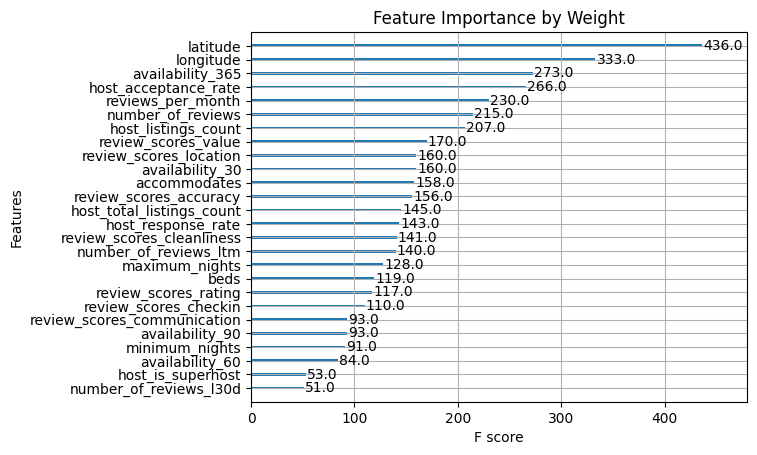

<Figure size 1000x800 with 0 Axes>

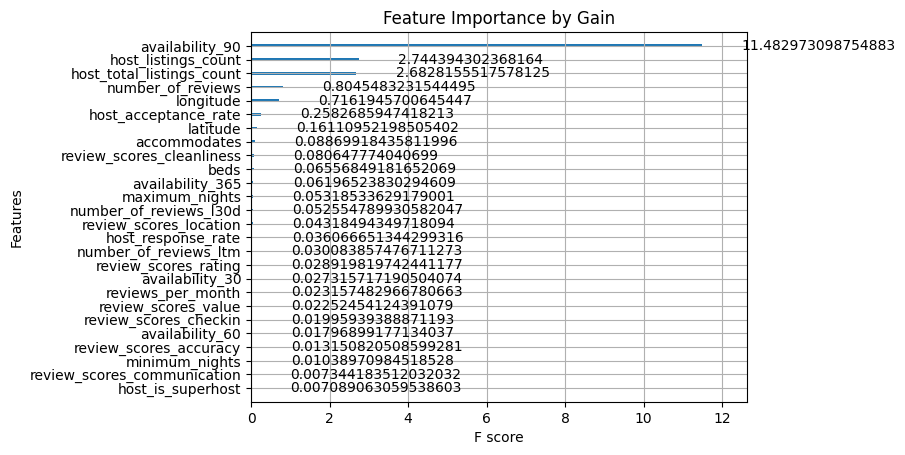

<Figure size 1000x800 with 0 Axes>

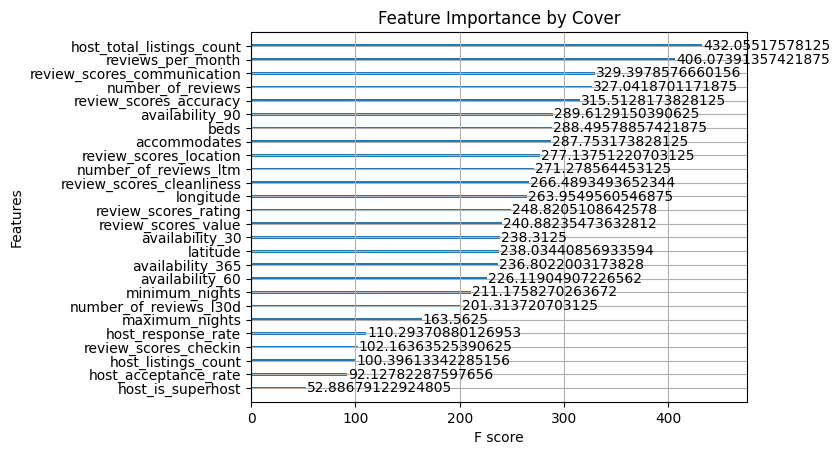

In [ ]:
#skoro wiem już ze XGboost zadziałał najlepiej to teraz chce się dowiedzieć które z cech miały najlepszy wpływ na wyjaśnialnośc ceny
import matplotlib.pyplot as plt
import xgboost as xgb

# Ważność cech za pomocą XGBoost
plt.figure(figsize=(10, 8))
xgb.plot_importance(xgb_model, importance_type='weight')
plt.title('Feature Importance by Weight')
plt.show()

plt.figure(figsize=(10, 8))
xgb.plot_importance(xgb_model, importance_type='gain')
plt.title('Feature Importance by Gain')
plt.show()

plt.figure(figsize=(10, 8))
xgb.plot_importance(xgb_model, importance_type='cover')
plt.title('Feature Importance by Cover')
plt.show()

# Definicje:

Importance Types (Typy Ważności Cech):

**weight (frequency):**
Definicja:
Liczba razy, kiedy dana cecha została użyta do podziału w drzewach decyzyjnych.

Znaczenie: Wskazuje, jak często dana cecha była używana do podejmowania decyzji w modelu. Większa liczba oznacza, że cecha była częściej używana i może być bardziej istotna dla modelu.
Kiedy używać: Dobry wskaźnik do zrozumienia, które cechy są najbardziej aktywnie używane przez model.

**gain:**

Definicja: Średni przyrost informacji (information gain) uzyskany dzięki użyciu danej cechy do podziału w drzewach.

Znaczenie: Mierzy, ile dana cecha przyczynia się do poprawy dokładności modelu. Wyższa wartość oznacza, że cecha ma większy wpływ na redukcję błędu modelu.
Kiedy używać: Najczęściej stosowany wskaźnik ważności, ponieważ bezpośrednio pokazuje, jak każda cecha wpływa na przewidywania modelu.

**cover:**

Definicja: Średnia liczba obserwacji (sample) obsługiwanych przez daną cechę w drzewach.

Znaczenie: Wskazuje, jak duża część danych była obsługiwana przez cechę podczas podziałów. Wyższa wartość oznacza, że cecha była używana do podziałów z większą liczbą próbek.
Kiedy używać: Pomocny wskaźnik do zrozumienia, jak cechy wpływają na rozkład danych w drzewach.

Jak przedstawić wyniki analiz ważności cech dla wirtualnego zarządu:
1. Streszczenie:
Przeanalizowaliśmy dane z portalu Airbnb, aby zidentyfikować kluczowe cechy, które wpływają na ceny wynajmu mieszkań w naszym mieście. Wykorzystaliśmy zaawansowane techniki uczenia maszynowego, w tym model XGBoost, aby uzyskać precyzyjne wyniki.

2. Kluczowe cechy wpływające na ceny:
Na podstawie naszych analiz zidentyfikowaliśmy kilka cech, które mają największy wpływ na ceny wynajmu mieszkań. Te cechy są najbardziej istotne i warto na nie zwrócić uwagę przy podejmowaniu decyzji biznesowych:

* availability_90 (Dostępność przez 90 dni): Mieszkania dostępne przez
dłuższy okres w roku są bardziej atrakcyjne dla wynajmujących, co może prowadzić do wyższych cen.
* host_listings_count (Liczba ofert gospodarza): Gospodarze z większą liczbą ofert mogą oferować lepsze warunki lub mają większe doświadczenie, co wpływa na wyższe ceny.
* host_total_listings_count (Łączna liczba ofert gospodarza): Podobnie jak liczba aktywnych ofert, łączna liczba ofert gospodarza również wpływa na ceny, sugerując, że bardziej doświadczeni gospodarze mogą uzyskiwać wyższe ceny.
* number_of_reviews (Liczba recenzji): Większa liczba recenzji często oznacza większą popularność i zaufanie do gospodarza, co może prowadzić do wyższych cen.
* longitude (Długość geograficzna): Lokalizacja geograficzna ma znaczący wpływ na ceny, co jest naturalne, biorąc pod uwagę atrakcyjność różnych obszarów miasta.

3. Jak te cechy wpływają na ceny:

Dostępność przez 90 dni (availability_90): Jeśli mieszkanie jest dostępne przez większość roku, oznacza to większy potencjalny zysk dla wynajmujących, co często prowadzi do wyższych cen.
Liczba ofert gospodarza (host_listings_count): Gospodarze, którzy mają więcej ofert, często są bardziej doświadczeni i mogą oferować lepsze usługi, co jest cenione przez najemców.
Łączna liczba ofert gospodarza (host_total_listings_count): Podobnie, większa liczba ofert wskazuje na doświadczenie i zaufanie do gospodarza.
Liczba recenzji (number_of_reviews): Mieszkania z większą liczbą recenzji są bardziej sprawdzone i zaufane przez klientów, co może wpłynąć na wyższą cenę.
Długość geograficzna (longitude): Położenie geograficzne ma naturalny wpływ na cenę wynajmu, gdzie niektóre obszary miasta są bardziej atrakcyjne i pożądane.

4. Wizualizacja wyników:
Na poniższych wykresach przedstawiamy, jak te cechy wpływają na ceny wynajmu. Każdy wykres pokazuje różne aspekty ważności cech: częstość użycia, przyrost informacji oraz zasięg danych, które obsługują te cechy.

5. Zalecenia dla zarządu:

Skupienie się na lokalizacji: Warto inwestować w mieszkania w bardziej atrakcyjnych lokalizacjach, które mogą przynosić wyższe ceny.
Zwiększanie dostępności: Utrzymywanie dostępności mieszkań przez dłuższy okres może zwiększyć ich atrakcyjność i cenę.
Wspieranie gospodarzy z większą liczbą ofert: Współpraca z bardziej doświadczonymi gospodarzami może prowadzić do lepszych wyników finansowych.
Zachęcanie do zbierania recenzji: Większa liczba pozytywnych recenzji może znacząco podnieść ceny wynajmu.
Wnioski:
Na podstawie naszych analiz, te cechy mają największy wpływ na kształtowanie cen wynajmu mieszkań w naszym mieście. Skupienie się na tych obszarach może pomóc w maksymalizacji zysków i poprawie strategii wynajmu.

In [ ]:
!pip install shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.5/540.5 kB 4.8 MB/s eta 0:00:00


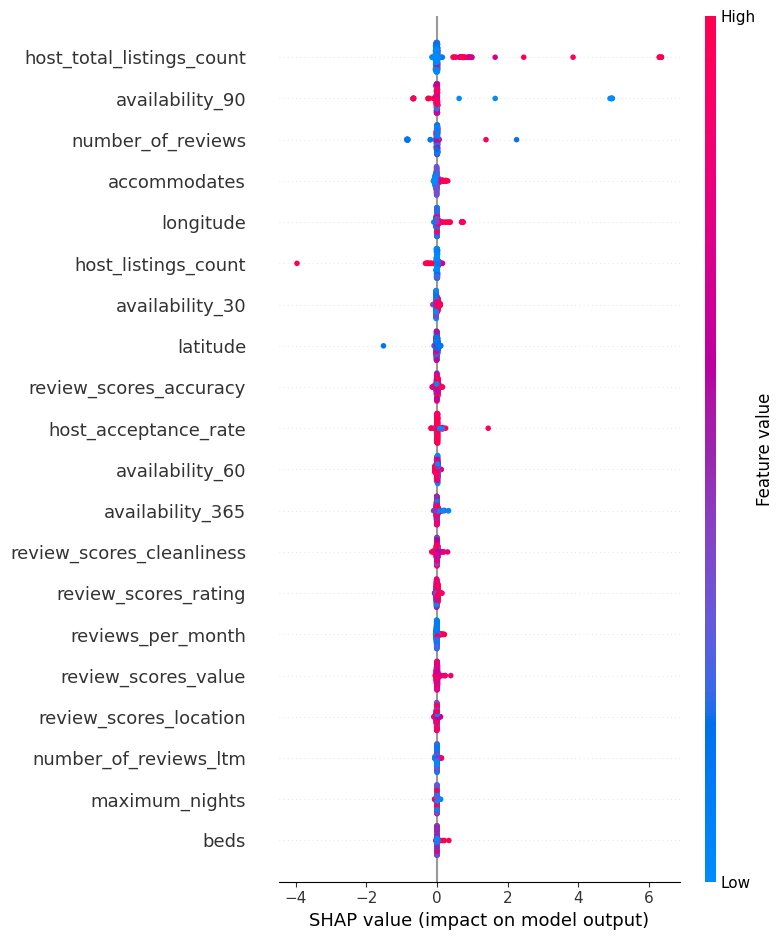

In [ ]:
import shap
import matplotlib.pyplot as plt

# Obliczanie wartości SHAP
explainer = shap.Explainer(xgb_model, X_train)
shap_values = explainer(X_test)

# Wizualizacja ważności cech za pomocą SHAP (ogólna)
shap.summary_plot(shap_values, X_test)

# Wizualizacja wartości SHAP dla pojedynczych przewidywań (szczegółowa)
shap.initjs()
# shap.force_plot(explainer.expected_value, shap_values[0,:], X_test.iloc[0,:])


Wynikowy wykres SHAP przedstawia, jak poszczególne cechy wpływają na przewidywane wartości modelu (w tym przypadku, ceny wynajmu mieszkań). Poniżej znajduje się interpretacja wykresu SHAP:

### Kluczowe elementy wykresu SHAP:
1. **Cechy**: Na osi Y widzimy listę cech.
2. **Wartości SHAP**: Na osi X widzimy wartości SHAP, które pokazują wpływ poszczególnych cech na przewidywania modelu.
3. **Kolor**: Kolor punktów reprezentuje wartość cechy – niebieski oznacza niską wartość cechy, a czerwony oznacza wysoką wartość cechy.
4. **Rozkład punktów**: Pokazuje, jak wartości SHAP są rozproszone dla różnych wartości cech.

### Jak przedstawić wyniki zarządowi:
1. **Streszczenie**:
   - "Używając zaawansowanej techniki SHAP, możemy zrozumieć, jak każda cecha wpływa na przewidywane ceny wynajmu mieszkań. Wartości SHAP pokazują zarówno globalne, jak i lokalne wpływy cech na model."

2. **Kluczowe cechy wpływające na ceny**:
   - **host_total_listings_count (Łączna liczba ofert gospodarza)**: Większa liczba ofert gospodarza znacząco zwiększa cenę.
   - **availability_90 (Dostępność przez 90 dni)**: Większa dostępność w ciągu 90 dni pozytywnie wpływa na cenę.
   - **number_of_reviews (Liczba recenzji)**: Więcej recenzji zwykle zwiększa zaufanie i cenę.
   - **accommodates (Liczba osób)**: Mieszkania mogące pomieścić więcej osób mają wyższe ceny.
   - **longitude (Długość geograficzna)**: Lokalizacja wpływa na cenę, z wyraźnym pozytywnym wpływem dla niektórych lokalizacji.

3. **Rekomendacje**:
   - **Zwiększanie liczby ofert**: Gospodarze z większą liczbą ofert mogą ustalać wyższe ceny.
   - **Zwiększenie dostępności**: Mieszkania dostępne przez większość roku są bardziej atrakcyjne i mogą przynosić wyższe ceny.
   - **Zbieranie recenzji**: Więcej recenzji może zwiększyć zaufanie i w rezultacie cenę wynajmu.
   - **Optymalizacja pojemności mieszkań**: Ustalanie cen w oparciu o liczbę osób, które mieszkanie może pomieścić.

### Podsumowanie:
Wartości SHAP pomagają zrozumieć, jak różne cechy wpływają na przewidywane ceny wynajmu mieszkań. Wyniki pokazują, że cechy takie jak liczba ofert gospodarza, dostępność, liczba recenzji i liczba osób mają największy wpływ na ceny. Zarząd powinien skupić się na optymalizacji tych cech, aby maksymalizować dochody.

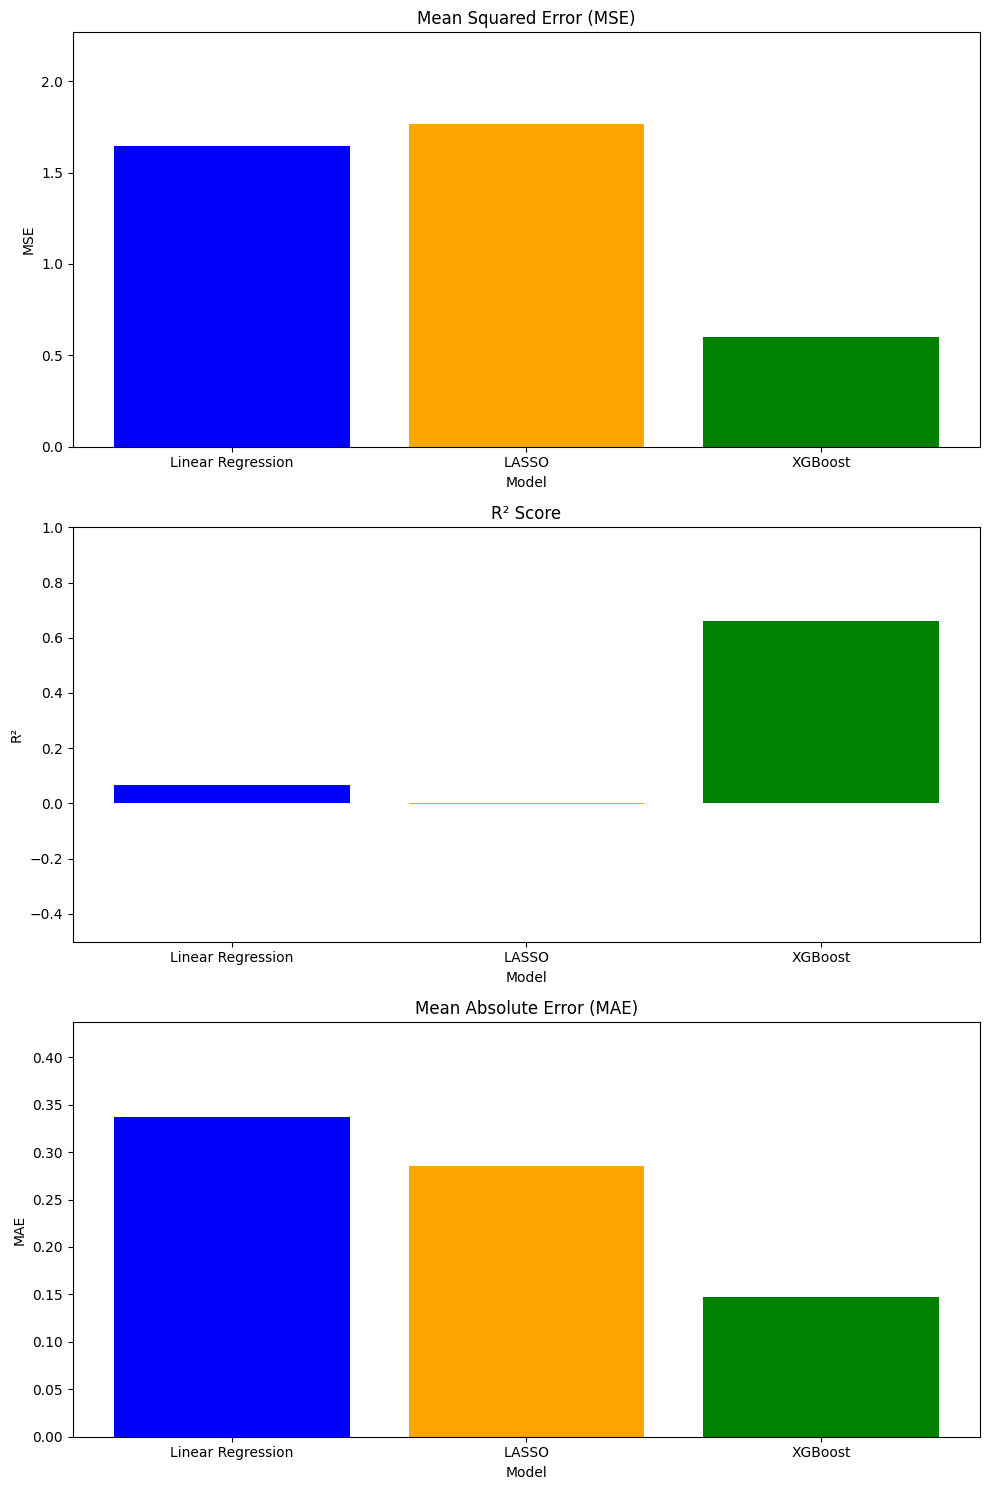

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Metryki dla poszczególnych modeli
metrics = {
    'Model': ['Linear Regression', 'LASSO', 'XGBoost'],
    'MSE': [1.6473892443182225, 1.767146867694824, 0.5978447108090423],
    'R²': [0.06688920043674573, -0.0009436642539439877, 0.6613700386586181],
    'MAE': [0.3367279550527636, 0.2851142107367719, 0.1475773348293922]
}

# Tworzenie DataFrame z metrykami
import pandas as pd
metrics_df = pd.DataFrame(metrics)

# Tworzenie wykresów słupkowych dla każdej metryki
fig, axs = plt.subplots(3, 1, figsize=(10, 15))

# Wykres dla MSE
axs[0].bar(metrics_df['Model'], metrics_df['MSE'], color=['blue', 'orange', 'green'])
axs[0].set_title('Mean Squared Error (MSE)')
axs[0].set_ylabel('MSE')
axs[0].set_ylim(0, max(metrics_df['MSE']) + 0.5)

# Wykres dla R²
axs[1].bar(metrics_df['Model'], metrics_df['R²'], color=['blue', 'orange', 'green'])
axs[1].set_title('R² Score - how many percents of price is explainable by model')
axs[1].set_ylabel('R²')
axs[1].set_ylim(min(metrics_df['R²']) - 0.5, 1)

# Wykres dla MAE
axs[2].bar(metrics_df['Model'], metrics_df['MAE'], color=['blue', 'orange', 'green'])
axs[2].set_title('Mean Absolute Error (MAE)')
axs[2].set_ylabel('MAE')
axs[2].set_ylim(0, max(metrics_df['MAE']) + 0.1)

# Ustawienia osi x
for ax in axs:
    ax.set_xlabel('Model')
    ax.set_xticks(np.arange(len(metrics_df['Model'])))
    ax.set_xticklabels(metrics_df['Model'])

plt.tight_layout()
plt.show()
